In [1]:
########################### xESMF Interpolate Sea ICe from HYCOM to ROMS ###########################
# The purpose of this script is to use the wonderful xesmf package to interpolate sea ice data
# from HYCOM data to the ROMS grid. This script then saves these values to the bry and clm files.

###### IMPORTANT NOTES ######
# - Remember that HYCOM lat/lon indices are not the same as ROMS grid lat/lon indices
#   - Important to keep in mind when comparing results
# - The model2roms workflow is to do the xesmf regridding then run the fill.f90
#   to get rid of any nans

##############################

In [2]:
# Load in packages
#%matplotlib widget # widget not currently working but instead prevents plots from showing
import matplotlib.pyplot as plt
#import ipywidgets as widgets
import numpy as np
import xarray as xr
import xesmf as xe
#import ESMF
import math
from netCDF4 import Dataset
from datetime import datetime, timedelta
from cftime import num2date, date2num
import pandas as pd 

In [3]:
# Load in the HYCOM sea ice data
# sea ice
hycom_ice = xr.open_dataset('/pscratch/sd/b/bundzis/External_data/HYCOM_data/hycom_daily_ncss/hycom_ice_2019_2024_daily_nogap.nc') # UPDATE PATH

In [4]:
# Cut out just the time period we care about for the model - the open water season
# We want all time 
# zeta
#hycom_zeta_all = hycom_zeta.sel(time=slice('2020-07-01','2020-11-01 21:00:00'))
#hycom_zeta_all = hycom_zeta.sel(time=slice('2020-07-01 09:00:00', '2020-11-02 09:00:00')) # this is 2019-07-01 01:00:00 - 2019-11-02 01:00:00 in AKDT
hycom_ice_all = hycom_ice
#print('hycom time length: ', len(hycom_zeta_all.time.values))
#print(hycom_zeta_all.time[-6:-1].values)
#input('press enter to continue...')

In [5]:
# Grid's lat/lon is in different convention than HYCOM lat/lon 
# need to make HYCOM match grid's lat lon convention 
hycom_ice_all['lon_180'] = -(360 - hycom_ice_all.lon.values)

In [6]:
# Load in the ROMS grid vertical coordinates
#grid = xr.open_dataset('/projects/brun1463/ROMS/Kakak3/Include/KakAKgrd_shelf_big010.nc')  #UPDATE PATH
grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_2020_test_nosed/Include/KakAKgrd_shelf_big010_smooth006_thin_sponge.nc')  #UPDATE PATH

In [7]:
# pull out the angle to rotate the currents to match the grid's u,v
phi = grid.angle[0,0].values # radians 

# Read in the dimensions
time_len = len(hycom_ice_all.time) # 984?
eta_rho_len = len(grid.eta_rho) # 206
xi_rho_len = len(grid.xi_rho) # 608
eta_u_len = len(grid.eta_u) # 206
xi_u_len = len(grid.xi_u) # 607
eta_v_len = len(grid.eta_v) # 205
xi_v_len = len(grid.xi_v) # 608

# Define other dimension lengths
# eta rho
Mp = len(grid.eta_rho)

# xi rho
Lp = len(grid.xi_rho)

# for u/v points 
Lm, Mm = (Lp-2), (Mp-2) #number/dimension of cells
L,  M  = Lm+1, Mm+1 #number/dimension of psi points

# latitude
lat_len = len(grid.lat_rho)

# longitude
lon_len = len(grid.lon_rho)

# time
# --- Below keeps things in UTC but we want AKDT--- 
# time_tmp_len = np.copy(time_len)
# time2_tmp_len = len(hycom_zeta_all.time)

# # make python do time to seconds 
# # make the hycom times into datetime
# datetime1 = pd.to_datetime(hycom_zeta_all.time.values)

# # convert all the times to seconds since 2000-01-01 (really 1999-12-31 so it start at beginning of year=hour 0)
# time_tmp = ((datetime1[:] - datetime(1999,12,31)).total_seconds() - 86400)
# #print(time_tmp[0:5])
# #print(len(time_tmp))
# #input('press enter to continue...')

# # HYCOM time 
# time_tmp2 = hycom_zeta_all.time.values
# ------

# --- AKDT version --- 
# Make a datetime array to use
# OLD 
# time_akdt = np.arange(datetime(2020,7,1,hour=1,minute=0,second=0), datetime(2020,11,2,hour=4,minute=0, second=0),timedelta(hours=3))
# time_akdt_dt = pd.to_datetime(time_akdt)
# time_tmp_len = len(time_akdt_dt)
# datetime1 = time_akdt_dt

# NEW
time_akdt = np.arange(datetime(2019,1,1,hour=1,minute=0,second=0), datetime(2024,9,6,hour=1,minute=0, second=0),timedelta(days=1))
time_akdt_dt = pd.to_datetime(time_akdt)
time_tmp_len = len(time_akdt_dt)
datetime1 = time_akdt_dt

# Convert all time to seconds since 2000-01-01 (really 1999-12-31 so it starts at beginning
# of year=hour 0)
time_tmp = ((datetime1[:] - datetime(1999,12,31)).total_seconds() - 86400)

# HYCOM time 
time_tmp2 = hycom_ice_all.time.values
time2_tmp_len = len(hycom_ice_all.time)
# ------

# name the variables to fill the netcdf 
# latitude
lat_tmp = grid.lat_rho.values

# longitude
lon_tmp = grid.lon_rho.values

# HYCOM number of lats
hycom_lat_len = len(hycom_ice_all.lat.values)
#print('hycom_lat_len', hycom_lat_len)

# HYCOM number of lons
hycom_lon_len = len(hycom_ice_all.lon.values)
#print('hycom_lon_len', hycom_lon_len)

In [8]:
time_tmp
print(datetime1[0])
print(time_tmp2[0])
print(datetime1[-1])
print(time_tmp2[-1])
print(time_tmp_len)
print(time2_tmp_len)

2019-01-01 01:00:00
2019-01-01T09:00:00.000000000
2024-09-05 01:00:00
2024-09-05T09:00:00.000000000
2075
2075


In [9]:
# Set up the netcdf for the climatology 
# ------------------------------- Create the netCDF file ---------------------------

#name of file I am writing to
ice_clm = '/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/Forcing_files/Bryclm/Attempt001/ice_clm_2019_2024_001.nc'   #UPDATE PATH

#create file to write to
nc1 = Dataset(ice_clm, 'w', format='NETCDF4')

#Global attributes
global_defaults = dict(gridname = 'KakAKgrd_shelf_big010_smooth006_thin_sponge.nc',
                      type = 'ROMS grid interpolated HYCOM ice climatology',
                      history = 'Created by Brianna Undzis',
                      Conventions = 'CF',
                      Institution = 'University of Colorado Boulder',
                      date = str(datetime.today()))
    
#create dictionary for model
d = {}
d = global_defaults

for att, value in d.items():
    setattr(nc1, att, value)

In [10]:
# Create dimensions
nc1.createDimension('xi_rho',  Lp)   # RHO
nc1.createDimension('eta_rho', Mp)
nc1.createDimension('xi_u',    L)    # u
nc1.createDimension('eta_u',   Mp)
nc1.createDimension('xi_v',    Lp)    # v
nc1.createDimension('eta_v',   M)
nc1.createDimension('ocean_time', None)
nc1.createDimension('one',     1)

<class 'netCDF4._netCDF4.Dimension'>: name = 'one', size = 1

In [11]:
# Create variables # this took several minutes (~9)
# --------------------
# Coordinate Variables
# --------------------
# xi rho
xi_rho = nc1.createVariable('xi_rho', 'd', ('xi_rho',), zlib=True)
xi_rho.long_name = 'xi coordinate of RHO-points'
xi_rho.standard_name = 'projection_xi_coordinate'
xi_rho.units = 'meter'
xi_rho_tmp = np.arange(0, Lp)
xi_rho[:] = xi_rho_tmp[:]

# eta rho
eta_rho = nc1.createVariable('eta_rho', 'd', ('eta_rho',), zlib=True)
eta_rho.long_name = 'eta coordinate of RHO-points'
eta_rho.standard_name = 'projection_eta_coordinate'
eta_rho.units = 'meter'
eta_rho_tmp = np.arange(0, Mp)
eta_rho[:] = eta_rho_tmp[:]

# ocean_time (in seconds)
ocean_time_g = nc1.createVariable('ocean_time', None, ('ocean_time'), zlib=True)
ocean_time_g.long_name = 'seconds since 2000-01-01 00:00:00' #with initialization of 2000-01-01 00:00:00
ocean_time_g.units = 'second'
ocean_time_g.field = 'time, scalar, series'
ocean_time_g[:] = time_tmp[:]


# --------------------
# Surface Elevation 
# --------------------

# --------------------
# Climatology Ice
# --------------------

# Sea Ice
# Ice area fraction (Aice) 
Aice_clm_g = nc1.createVariable('Aice', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
Aice_clm_g.standard_name = 'sea_ice_area_fraction'
Aice_clm_g.long_name = 'fraction of cell covered by ice'
Aice_clm_g.units = 'nondimensional'
#Aice_clm_g[:,:,:] = ice_zeros_clm

# Ice thickness (ice_thickness) 
ice_thickness_clm_g = nc1.createVariable('ice_thickness', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
ice_thickness_clm_g.standard_name = 'sea_ice_thickness'
ice_thickness_clm_g.long_name = 'average ice thickness in cell'
ice_thickness_clm_g.units = 'meter'
#ice_thickness_clm_g[:,:,:] = ice_zeros_clm

# Meltpond thickness (meltpond_thickness)
# meltpond_thickness_g = nc1.createVariable('meltpond_thickness', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# meltpond_thickness_g.standard_name = 'melt_pond_water_thickness_on_sea_ice'
# meltpond_thickness_g.long_name = 'surface melt water thickness on ice'
# meltpond_thickness_g.units = 'meter'
# meltpond_thickness_g[:,:,:] = meltpond_thickness_tmp 

# Ice age (ice_age) 
# I do not have HYCOM data for this so leaving it out for now
# ice_age_clm_g = nc1.createVariable('ice_age', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# ice_age_clm_g.standard_name = 'age_of_sea_ice'
# ice_age_clm_g.long_name = 'age of sea ice'
# ice_age_clm_g.units = 'second'
# #ice_age_clm_g[:,:,:] = ice_zeros_clm

# Snow thickness (snow_thickness) 
# I do not have HYCOM data for this so leaving it out for now
# snow_thickness_clm_g = nc1.createVariable('snow_thickness', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# snow_thickness_clm_g.standard_name = 'snowfall_thickness_above_sea_ice'
# snow_thickness_clm_g.long_name = 'thickness of snow cover'
# snow_thickness_clm_g.units = 'meter'
# #snow_thickness_clm_g[:,:,:] = ice_zeros_clm  

# # Sea ice temperature (sea_ice_temperature)
# tice_g = nc1.createVariable('Tice', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# tice_g.standard_name = 'sea_ice_temperature'
# tice_g.long_name = 'interior ice temperature'
# tice_g.units = 'Celcius'
# tice_g[:,:] = ice_temp_tmp

# # Under ice temperature (under_ice_temp)
# under_ice_temp_g = nc1.createVariable('under_ice_temp', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# under_ice_temp_g.standard_name = 'temperature_of_molecular_sub_layer_under_sea_ice'
# under_ice_temp_g.long_name = 'temperature of molecular sub-layer under ice'
# under_ice_temp_g.units = 'Celcius'
# under_ice_temp_g[:,:] = under_ice_temp_tmp

# # Under ice salinity (under_ice_salt)
# under_ice_salt_g = nc1.createVariable('under_ice_salt', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# under_ice_salt_g.standard_name = 'salinity_of_molecular_sub_layer_under_sea_ice'
# under_ice_salt_g.long_name = 'salinity of molecular sub-layer under ice'
# under_ice_salt_g.units = 'Celcius'
# under_ice_salt_g[:,:] = under_ice_salt_tmp

# Sea ice surface temperature  (ice_sst)
# I do not have HYCOM data for this so leaving it out for now
# sea_ice_surface_temperature_clm_g = nc1.createVariable('ice_sst', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# sea_ice_surface_temperature_clm_g.standard_name = 'sea_ice_surface_temperature'
# sea_ice_surface_temperature_clm_g.long_name = 'temperature of ice/snow surface'
# sea_ice_surface_temperature_clm_g.units = 'Celcius'
# #sea_ice_surface_temperature_clm_g[:,:,:] = ice_zeros_clm

# Ice u-velocity (Uice) 
Uice_clm_g = nc1.createVariable('Uice', 'f8', ('ocean_time', 'eta_u', 'xi_u'), zlib=True)
Uice_clm_g.standard_name = 'sea_ice_x_velocity'
Uice_clm_g.long_name = 'u-component of ice velocity'
Uice_clm_g.units = 'meter second-1'
#Uice_clm_g[:,:,:] = ice_zeros_clm_u

# Ice v-velocity (Vice)
Vice_clm_g = nc1.createVariable('Vice', 'f8', ('ocean_time', 'eta_v', 'xi_v'), zlib=True)
Vice_clm_g.standard_name = 'sea_ice_y_velocity'
Vice_clm_g.long_name = 'v-component of ice velocity'
Vice_clm_g.units = 'meter second-1'
#Vice_clm_g[:,:,:] = ice_zeros_clm_v

In [12]:
# Set up the netcdf for the boundary 
# ------------------------------- Create the netCDF file ---------------------------

#name of file I am writing to
ice_bry = '/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/Forcing_files/Bryclm/Attempt001/ice_bry_2019_2024_001.nc'   #UPDATE PATH

#create file to write to
nc2 = Dataset(ice_bry, 'w', format='NETCDF4')

#Global attributes
global_defaults = dict(gridname = 'KakAKgrd_shelf_big010_smooth006_thin_sponge.nc',
                      type = 'ROMS grid interpolated HYCOM ice boundary',
                      history = 'Created by Brianna Undzis',
                      Conventions = 'CF',
                      Institution = 'University of Colorado Boulder',
                      date = str(datetime.today()))
    
#create dictionary for model
d = {}
d = global_defaults

for att, value in d.items():
    setattr(nc2, att, value)

In [13]:
# Create dimensions
nc2.createDimension('xi_rho',  Lp)   # RHO
nc2.createDimension('eta_rho', Mp)
nc2.createDimension('xi_u',    L)    # u
nc2.createDimension('eta_u',   Mp)
nc2.createDimension('xi_v',    Lp)    # v
nc2.createDimension('eta_v',   M)
nc2.createDimension('ocean_time', None)
nc2.createDimension('one',     1)

<class 'netCDF4._netCDF4.Dimension'>: name = 'one', size = 1

In [14]:
# Create variables
# --------------------
# Coordinate Variables
# --------------------
# xi rho
xi_rho = nc2.createVariable('xi_rho', 'd', ('xi_rho',), zlib=True)
xi_rho.long_name = 'xi coordinate of RHO-points'
xi_rho.standard_name = 'projection_xi_coordinate'
xi_rho.units = 'meter'
xi_rho_tmp = np.arange(0, Lp)
xi_rho[:] = xi_rho_tmp[:]

# eta rho
eta_rho = nc2.createVariable('eta_rho', 'd', ('eta_rho',), zlib=True)
eta_rho.long_name = 'eta coordinate of RHO-points'
eta_rho.standard_name = 'projection_eta_coordinate'
eta_rho.units = 'meter'
eta_rho_tmp = np.arange(0, Mp)
eta_rho[:] = eta_rho_tmp[:]

# ocean_time (in seconds)
ocean_time_g = nc2.createVariable('ocean_time', None, ('ocean_time'), zlib=True)
ocean_time_g.long_name = 'seconds since 2000-01-01 00:00:00' #with initialization of 2000-01-01 00:00:00
ocean_time_g.units = 'second'
ocean_time_g.field = 'time, scalar, series'
ocean_time_g[:] = time_tmp[:]
    

# --------------------
# Boundary Ice
# --------------------

# Sea Ice
# Ice area fraction (Aice) - west
Aice_west_bry_g = nc2.createVariable('Aice_west', 'f8', ('ocean_time', 'eta_rho'), zlib=True)
Aice_west_bry_g.standard_name = 'sea_ice_area_fraction'
Aice_west_bry_g.long_name = 'fraction of cell covered by ice at western boundary'
Aice_west_bry_g.units = 'nondimensional'
#Aice_west_bry_g[:,:] = ice_zeros_west 

# Ice area fraction (Aice) - north
Aice_north_bry_g = nc2.createVariable('Aice_north', 'f8', ('ocean_time', 'xi_rho'), zlib=True)
Aice_north_bry_g.standard_name = 'sea_ice_area_fraction'
Aice_north_bry_g.long_name = 'fraction of cell covered by ice at northern boundary'
Aice_north_bry_g.units = 'nondimensional'
#Aice_north_bry_g[:,:] = ice_zeros_north 

# Ice area fraction (Aice) - east
Aice_east_bry_g = nc2.createVariable('Aice_east', 'f8', ('ocean_time', 'eta_rho'), zlib=True)
Aice_east_bry_g.standard_name = 'sea_ice_area_fraction'
Aice_east_bry_g.long_name = 'fraction of cell covered by ice at eastern boundary'
Aice_east_bry_g.units = 'nondimensional'
#Aice_east_bry_g[:,:] = ice_zeros_east 

# Ice thickness (ice_thickness) - west
ice_thickness_west_g = nc2.createVariable('ice_thickness_west', 'f8', ('ocean_time', 'eta_rho'), zlib=True)
ice_thickness_west_g.standard_name = 'sea_ice_thickness_west'
ice_thickness_west_g.long_name = 'average ice thickness in cell at western boundary'
ice_thickness_west_g.units = 'meter'
#ice_thickness_west_g[:,:] = ice_zeros_west 

# Ice thickness (ice_thickness) - north
ice_thickness_north_g = nc2.createVariable('ice_thickness_north', 'f8', ('ocean_time', 'xi_rho'), zlib=True)
ice_thickness_north_g.standard_name = 'sea_ice_thickness_north'
ice_thickness_north_g.long_name = 'average ice thickness in cell at northern boundary'
ice_thickness_north_g.units = 'meter'
#ice_thickness_north_g[:,:] = ice_zeros_north

# Ice thickness (ice_thickness) - east
ice_thickness_east_g = nc2.createVariable('ice_thickness_east', 'f8', ('ocean_time', 'eta_rho'), zlib=True)
ice_thickness_east_g.standard_name = 'sea_ice_thickness_east'
ice_thickness_east_g.long_name = 'average ice thickness in cell at eastern boundary'
ice_thickness_east_g.units = 'meter'
#ice_thickness_east_g[:,:] = ice_zeros_east

# Meltpond thickness (meltpond_thickness)
# meltpond_thickness_g = nc.createVariable('meltpond_thickness', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# meltpond_thickness_g.standard_name = 'melt_pond_water_thickness_on_sea_ice'
# meltpond_thickness_g.long_name = 'surface melt water thickness on ice'
# meltpond_thickness_g.units = 'meter'
# meltpond_thickness_g[:,:,:] = meltpond_thickness_tmp 

# Ice age (ice_age) - west
# I do not have HYCOM data for this so leaving it out for now
# ice_age_west_g = nc.createVariable('ice_age_west', 'f8', ('ocean_time', 'eta_rho'), zlib=True)
# ice_age_west_g.standard_name = 'age_of_sea_ice'
# ice_age_west_g.long_name = 'age of sea ice at western boundary'
# ice_age_west_g.units = 'second'
# ice_age_west_g[:,:] = ice_zeros_west

# # Ice age (ice_age) - north
# ice_age_north_g = nc.createVariable('ice_age_north', 'f8', ('ocean_time', 'xi_rho'), zlib=True)
# ice_age_north_g.standard_name = 'age_of_sea_ice'
# ice_age_north_g.long_name = 'age of sea ice at northern boundary'
# ice_age_north_g.units = 'second'
# ice_age_north_g[:,:] = ice_zeros_north

# # Ice age (ice_age) - east
# ice_age_east_g = nc.createVariable('ice_age_east', 'f8', ('ocean_time', 'eta_rho'), zlib=True)
# ice_age_east_g.standard_name = 'age_of_sea_ice'
# ice_age_east_g.long_name = 'age of sea ice at eastern boundary'
# ice_age_east_g.units = 'second'
# ice_age_east_g[:,:] = ice_zeros_east

# Snow thickness (snow_thickness) - west
# I do not have HYCOM data for this so leaving it out for now
# snow_thickness_west_g = nc.createVariable('snow_thickness_west', 'f8', ('ocean_time', 'eta_rho'), zlib=True)
# snow_thickness_west_g.standard_name = 'snowfall_thickness_above_sea_ice'
# snow_thickness_west_g.long_name = 'thickness of snow cover at western boundary'
# snow_thickness_west_g.units = 'meter'
# snow_thickness_west_g[:,:] = ice_zeros_west 

# # Snow thickness (snow_thickness) - north
# snow_thickness_north_g = nc.createVariable('snow_thickness_north', 'f8', ('ocean_time', 'xi_rho'), zlib=True)
# snow_thickness_north_g.standard_name = 'snowfall_thickness_above_sea_ice'
# snow_thickness_north_g.long_name = 'thickness of snow cover at northern boundary'
# snow_thickness_north_g.units = 'meter'
# snow_thickness_north_g[:,:] = ice_zeros_north 

# # Snow thickness (snow_thickness) - east
# snow_thickness_east_g = nc.createVariable('snow_thickness_east', 'f8', ('ocean_time', 'eta_rho'), zlib=True)
# snow_thickness_east_g.standard_name = 'snowfall_thickness_above_sea_ice'
# snow_thickness_east_g.long_name = 'thickness of snow cover at eastern boundary'
# snow_thickness_east_g.units = 'meter'
# snow_thickness_east_g[:,:] = ice_zeros_east 

# # Sea ice temperature (sea_ice_temperature)
# tice_g = nc.createVariable('Tice', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# tice_g.standard_name = 'sea_ice_temperature'
# tice_g.long_name = 'interior ice temperature'
# tice_g.units = 'Celcius'
# tice_g[:,:] = ice_temp_tmp

# # Under ice temperature (under_ice_temp)
# under_ice_temp_g = nc.createVariable('under_ice_temp', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# under_ice_temp_g.standard_name = 'temperature_of_molecular_sub_layer_under_sea_ice'
# under_ice_temp_g.long_name = 'temperature of molecular sub-layer under ice'
# under_ice_temp_g.units = 'Celcius'
# under_ice_temp_g[:,:] = under_ice_temp_tmp

# # Under ice salinity (under_ice_salt)
# under_ice_salt_g = nc.createVariable('under_ice_salt', 'f8', ('ocean_time', 'eta_rho', 'xi_rho'), zlib=True)
# under_ice_salt_g.standard_name = 'salinity_of_molecular_sub_layer_under_sea_ice'
# under_ice_salt_g.long_name = 'salinity of molecular sub-layer under ice'
# under_ice_salt_g.units = 'Celcius'
# under_ice_salt_g[:,:] = under_ice_salt_tmp

# Sea ice surface temperature  (ice_sst) - west
# I do not have HYCOM data for this so leaving it out for now
# sea_ice_surface_temperature_west_g = nc.createVariable('ice_sst_west', 'f8', ('ocean_time', 'eta_rho'), zlib=True)
# sea_ice_surface_temperature_west_g.standard_name = 'sea_ice_surface_temperature'
# sea_ice_surface_temperature_west_g.long_name = 'temperature of ice/snow surface at western boundary'
# sea_ice_surface_temperature_west_g.units = 'Celcius'
# sea_ice_surface_temperature_west_g[:,:] = ice_zeros_west

# # Sea ice surface temperature  (ice_sst) - north
# sea_ice_surface_temperature_north_g = nc.createVariable('ice_sst_north', 'f8', ('ocean_time', 'xi_rho'), zlib=True)
# sea_ice_surface_temperature_north_g.standard_name = 'sea_ice_surface_temperature'
# sea_ice_surface_temperature_north_g.long_name = 'temperature of ice/snow surface at northern boundary'
# sea_ice_surface_temperature_north_g.units = 'Celcius'
# sea_ice_surface_temperature_north_g[:,:] = ice_zeros_north

#  # Sea ice surface temperature  (ice_sst) - east
# sea_ice_surface_temperature_east_g = nc.createVariable('ice_sst_east', 'f8', ('ocean_time', 'eta_rho'), zlib=True)
# sea_ice_surface_temperature_east_g.standard_name = 'sea_ice_surface_temperature'
# sea_ice_surface_temperature_east_g.long_name = 'temperature of ice/snow surface at eastern boundary'
# sea_ice_surface_temperature_east_g.units = 'Celcius'
# sea_ice_surface_temperature_east_g[:,:] = ice_zeros_east

# Ice u-velocity (Uice) - west
Uice_west_g = nc2.createVariable('Uice_west', 'f8', ('ocean_time', 'eta_u'), zlib=True)
Uice_west_g.standard_name = 'sea_ice_x_velocity'
Uice_west_g.long_name = 'u-component of ice velocity at western boundary'
Uice_west_g.units = 'meter second-1'
#Uice_west_g[:,:] = ice_zeros_west_u 

# Ice u-velocity (Uice) - north
Uice_north_g = nc2.createVariable('Uice_north', 'f8', ('ocean_time', 'xi_u'), zlib=True)
Uice_north_g.standard_name = 'sea_ice_x_velocity'
Uice_north_g.long_name = 'u-component of ice velocity at northern boundary'
Uice_north_g.units = 'meter second-1'
#Uice_north_g[:,:] = ice_zeros_north_u 

# Ice u-velocity (Uice) - east
Uice_east_g = nc2.createVariable('Uice_east', 'f8', ('ocean_time', 'eta_u'), zlib=True)
Uice_east_g.standard_name = 'sea_ice_x_velocity'
Uice_east_g.long_name = 'u-component of ice velocity at eastern boundary'
Uice_east_g.units = 'meter second-1'
#Uice_east_g[:,:] = ice_zeros_east_u 

# Ice v-velocity (Vice) - west
Vice_west_g = nc2.createVariable('Vice_west', 'f8', ('ocean_time', 'eta_v'), zlib=True)
Vice_west_g.standard_name = 'sea_ice_y_velocity'
Vice_west_g.long_name = 'v-component of ice velocity at western boundary'
Vice_west_g.units = 'meter second-1'
#Vice_west_g[:,:] = ice_zeros_west_v 

# Ice v-velocity (Vice) - north
Vice_north_g = nc2.createVariable('Vice_north', 'f8', ('ocean_time', 'xi_v'), zlib=True)
Vice_north_g.standard_name = 'sea_ice_y_velocity'
Vice_north_g.long_name = 'v-component of ice velocity at northern boundary'
Vice_north_g.units = 'meter second-1'
#Vice_north_g[:,:] = ice_zeros_north_v 

# Ice v-velocity (Vice) - east
Vice_east_g = nc2.createVariable('Vice_east', 'f8', ('ocean_time', 'eta_v'), zlib=True)
Vice_east_g.standard_name = 'sea_ice_y_velocity'
Vice_east_g.long_name = 'v-component of ice velocity at eastern boundary'
Vice_east_g.units = 'meter second-1'
#Vice_east_g[:,:] = ice_zeros_east_v 

In [15]:
# Set the input and output grids, and sepcify the lat/lon
# Since we are looking at zeta for now, we will use lon_rho and lat_rho as the primary lat/lon for the grid 
# Input grid (HYCOM)
ds_in_hycom = hycom_ice_all.copy() # need to use lon_180 for this grid 
ds_in_hycom['lon_360'] = ds_in_hycom.lon.values
ds_in_hycom['lon'] = ds_in_hycom.lon_180.values

# Output grid (ROMS rho grid)
#ds_out_rho = grid_vertical
ds_out_rho = grid.copy()
ds_out_rho['lat'] = (('eta_rho', 'xi_rho'), ds_out_rho.lat_rho.values)
ds_out_rho['lon'] = (('eta_rho', 'xi_rho'), ds_out_rho.lon_rho.values)

# Output grid (ROMS u grid, but keeps HYCOM vertical levels)
ds_out_u = grid.copy()
ds_out_u['lat'] = (('eta_u', 'xi_u'), ds_out_u.lat_u.values)
ds_out_u['lon'] = (('eta_u', 'xi_u'), ds_out_u.lon_u.values)

# Output grid (ROMS, but keeps HYCOM vertical levels)
ds_out_v = grid.copy()
ds_out_v['lat'] = (('eta_v', 'xi_v'), ds_out_v.lat_v.values)
ds_out_v['lon'] = (('eta_v', 'xi_v'), ds_out_v.lon_v.values)

# Add masks 
# ex: ds["mask"] = xr.where(~np.isnan(ds["zeta"].isel(ocean_time=0)), 1, 0)
# Input grid (HYCOM)
# this is only a surface mask - which is what we want 
ds_in_hycom_mask = xr.where(~np.isnan(ds_in_hycom['sic'][0,:,:].values), 1, 0) 
ds_in_hycom['mask'] = (('lat', 'lon'), ds_in_hycom_mask)

# Output grid (ROMS rho grid)
ds_out_rho['mask'] = (('eta_rho', 'xi_rho'), ds_out_rho.mask_rho.values)

# Output grid (ROMS u)
ds_out_u['mask'] = (('eta_u', 'xi_u'), ds_out_u.mask_u.values)

# Output grid (ROMS v grid)
ds_out_v['mask'] = (('eta_v', 'xi_v'), ds_out_v.mask_v.values)

In [16]:
# Regrid from HYCOM grid to rho grid with the masks included and extrapolation used 
regridder_hycom2rho = xe.Regridder(ds_in_hycom, ds_out_rho, method="bilinear", extrap_method='nearest_s2d') #extrap_method="nearest_s2d"
regridder_hycom2rho

xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_126x238_206x608.nc 
Reuse pre-computed weights? False 
Input grid shape:           (126, 238) 
Output grid shape:          (206, 608) 
Periodic in longitude?      False

In [17]:
# Regrid from HYCOM grid to u grid with the masks included and extrapolation used 
regridder_hycom2u = xe.Regridder(ds_in_hycom, ds_out_u, method="bilinear", extrap_method='nearest_s2d') #extrap_method="nearest_s2d"
regridder_hycom2u

# Save the weights - only need to do this once
#fn_hycom2rho = regridder_hycom2rho.to_netcdf('regrid_hycom2rho_weights.nc')
#print(fn_hycom2u)

xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_126x238_206x607.nc 
Reuse pre-computed weights? False 
Input grid shape:           (126, 238) 
Output grid shape:          (206, 607) 
Periodic in longitude?      False

In [18]:
# Regrid from HYCOM grid to v grid with the masks included and extrapolation used 
regridder_hycom2v = xe.Regridder(ds_in_hycom, ds_out_v, method="bilinear", extrap_method='nearest_s2d') #extrap_method="nearest_s2d"
regridder_hycom2v

xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_126x238_205x608.nc 
Reuse pre-computed weights? False 
Input grid shape:           (126, 238) 
Output grid shape:          (205, 608) 
Periodic in longitude?      False

In [19]:
# Now use the regridder/weights to regrid sea ice concentration/area fraction   
dr_hycom2rho_sic = hycom_ice_all['sic'].copy()
dr_out_hycom2rho_sic = regridder_hycom2rho(dr_hycom2rho_sic) 
dr_out_hycom2rho_sic

<xarray.DataArray (time: 2075, eta_rho: 206, xi_rho: 608)> Size: 2GB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.99939996, 0.99939996, 0.99939996, ..., 0.99789995,
         0.99789995, 0.99789995],
        [0.99939996, 0.99939996, 0.99939996, ..., 0.99789995,
         0.99789995, 0.99789995],
        [0.99939996, 0.99939996, 0.99939996, ..., 0.99789995,
         0.99789995, 0.99789995]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]]])
Coordinates:
  * time     (time) datetime64[ns] 17kB 2019-01-01T09:00:00 ... 2024-09-05T09...
  * xi_rho   (xi_rho) float64 5kB 0.0 1.0 2.0 3.0 ... 604.0 605.0 606.0 607.0
  * eta_rho  (eta_rho) float64 2kB 0.0 1.0 2.0 3.0 ... 202.0 203.0 204.0 205.0
    lon_rho  (eta_rho, xi_rho) float64 1MB -153.7 -153.6 ... -141.2 -141.1
    lat_rho  (eta_rho, xi_rho) float64 1MB 70.38 70.38 70.38 ... 70.72 70.71
Attributes:
    regrid_method:  bilinear

In [20]:
# Now use the regridder/weights to regrid sea ice thickness 
dr_hycom2rho_sih = hycom_ice_all['sih'].copy()
dr_out_hycom2rho_sih = regridder_hycom2rho(dr_hycom2rho_sih) 
dr_out_hycom2rho_sih

<xarray.DataArray (time: 2075, eta_rho: 206, xi_rho: 608)> Size: 2GB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [1.75477774, 1.75152991, 1.74824769, ..., 1.15584605,
         1.16248635, 1.16912628],
        [1.74641733, 1.74334042, 1.74022908, ..., 1.14661943,
         1.15326055, 1.15990129],
        [1.73807892, 1.73517301, 1.73223266, ..., 1.13739305,
         1.14403499, 1.15067655]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]])
Coordinates:
  * time     (time) datetime64[ns] 17kB 2019-01-01T09:00:00 ... 2024-09-05T09...
  * xi_rho   (xi_rho) float64 5kB 0.0 1.0 2.0 3.0 ... 604.0 605.0 606.0 607.0
  * eta_rho  (eta_rho) float64 2kB 0.0 1.0 2.0 3.0 ... 202.0 203.0 204.0 205.0
    lon_rho  (eta_rho, xi_rho) float64 1MB -153.7 -153.6 ... -141.2 -141.1
    lat_rho  (eta_rho, xi_rho) float64 1MB 70.38 70.38 70.38 ... 70.72 70.71
Attributes:
    regrid_method:  bilinear

In [21]:
# Need to rotate u and v before interpolating them
# ** Only needed if not reading from clm file **
# Now before we can regird and such, we need to rotate the HYCOM data
# Define a function to do this rotation 
def rotate2(point, angle):
    """
    Rotate a point counterclockwise by a given angle around a given origin.

    The angle should be given in radians.
    
    This equation can be verified here: https://www.myroms.org/forum/viewtopic.php?f=3&t=295 
    where we are rotating from lon,lat to the same lon,lat (rotating HYCOM data about an angle)
    """
    px, py = point

    qx = math.cos(angle) * (px) - math.sin(angle) * (py)
    qy = math.sin(angle) * (px) + math.cos(angle) * (py)
    return qx, qy

In [22]:
# Apply this rotation to all u and v in HYCOM
# Declare empty arrays to fill with the rotated values 
ice_u_rot = np.empty((time_len,hycom_lat_len,hycom_lon_len)) # only one time since this is initial conditions file 
ice_v_rot = np.empty((time_len,hycom_lat_len,hycom_lon_len))

# Rotate the currents and save the values to the arrays; this takes ~1 minute
ice_u_rot[:,:,:], ice_v_rot[:,:,:] = rotate2((hycom_ice_all.siu[:,:,:].values, hycom_ice_all.siv[:,:,:].values), phi)

# Check to see if this rotation worked 
# # check u
# print('Unrotated u: ', hycom_ice_data.ssu[0,80,200].values)
# print('Expected rotated u: ', math.cos(phi) * (hycom_ice_data.ssu[0,80,200].values) - math.sin(phi) * (hycom_ice_data.ssv[0,80,200].values))
# print('Actual Rotated u: ', ice_u_rot[0,80,200])

# # check v
# print('Unrotated v: ', hycom_ice_data.ssv[0,80,200].values)
# print('Expected rotated v: ', math.sin(phi) * (hycom_ice_data.ssu[0,80,200].values) + math.cos(phi) * (hycom_ice_data.ssv[0,80,200].values))
# print('Actual Rotated v: ', ice_v_rot[0,80,200])

In [23]:
# This rotation seemed to work correctly and was super fast!! So yay! 
# Now make these rotated currents part of the HYCOM data set
# ex: ds['nmap'] = (('y', 'x'), nmap)
hycom_ice_all['ice_u_rot'] = (('time', 'lat', 'lon'), ice_u_rot)
hycom_ice_all['ice_v_rot'] = (('time', 'lat', 'lon'), ice_v_rot)

In [24]:
# Now use the regridder/weights to regrid the pre-rotated water u 
dr_hycom2u_siu = hycom_ice_all['ice_u_rot'].copy()
dr_hycom2u_siu = regridder_hycom2u(dr_hycom2u_siu)
dr_hycom2u_siu

<xarray.DataArray (time: 2075, eta_u: 206, xi_u: 607)> Size: 2GB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.18948726, -0.18951038, -0.18955745, ..., -0.16406741,
         -0.16389731, -0.16373405],
        [-0.18963451, -0.18964813, -0.18969194, ..., -0.1642999 ,
         -0.16408764, -0.16389765],
        [-0.18978054, -0.18978464, -0.18982212, ..., -0.16450275,
         -0.16426373, -0.16404698]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
  * time     (time) datetime64[ns] 17kB 2019-01-01T09:00:00 ... 2024-09-05T09...
  * xi_u     (xi_u) float64 5kB 0.0 1.0 2.0 3.0 4.0 ... 603.0 604.0 605.0 606.0
  * eta_u    (eta_u) float64 2kB 0.0 1.0 2.0 3.0 4.0 ... 202.0 203.0 204.0 205.0
    lon_u    (eta_u, xi_u) float64 1MB -153.7 -153.6 -153.6 ... -141.2 -141.2
    lat_u    (eta_u, xi_u) float64 1MB 70.38 70.38 70.38 ... 70.72 70.72 70.72
Attributes:
    regrid_method:  bilinear

In [25]:
# Now use the regridder/weights to regrid the pre-rotated water v
dr_hycom2v_siv = hycom_ice_all['ice_v_rot'].copy()
dr_hycom2v_siv = regridder_hycom2v(dr_hycom2v_siv)
dr_hycom2v_siv

<xarray.DataArray (time: 2075, eta_v: 205, xi_v: 608)> Size: 2GB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.09550418, 0.09535831, 0.09520575, ..., 0.05337869,
         0.05308306, 0.05279389],
        [0.09545347, 0.09534062, 0.09522107, ..., 0.05337944,
         0.05307605, 0.05277912],
        [0.09540704, 0.09532722, 0.09524071, ..., 0.05337605,
         0.0530649 , 0.05276021]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]])
Coordinates:
  * time     (time) datetime64[ns] 17kB 2019-01-01T09:00:00 ... 2024-09-05T09...
  * xi_v     (xi_v) float64 5kB 0.0 1.0 2.0 3.0 4.0 ... 604.0 605.0 606.0 607.0
  * eta_v    (eta_v) float64 2kB 0.0 1.0 2.0 3.0 4.0 ... 201.0 202.0 203.0 204.0
    lon_v    (eta_v, xi_v) float64 997kB -153.7 -153.6 -153.6 ... -141.2 -141.1
    lat_v    (eta_v, xi_v) float64 997kB 70.39 70.38 70.38 ... 70.72 70.71 70.71
Attributes:
    regrid_method:  bilinear

In [26]:
# Use fill.f90 to fill the nans in the array
# Import fill.f90 from model2roms to see how to 
# use this/if it can be used to get rid of nans 
# from numpy import f2py
# with open('/global/homes/b/bundzis/Projects/Beaufort_ROMS_2020_dvd_myroms_ice/Scripts/Forcing_files/Bryclm/fill.f90') as sourcefile2:
#     sourcecode2 = sourcefile2.read()
# f2py.compile(sourcecode2, modulename='fill', extension='.f90')
#import fill

# This does not work anymore so instead conda activate py311env, then f2py -c -m fill fill.f90

In [27]:
import fill

In [28]:
# Define a function to call to do the filling, taken from model2roms
def laplacefilter(field, threshold, toxi, toeta):
    undef = 2.0e+35 
    tx = 0.9 * undef
    critx = 0.01
    cor = 1.6
    mxs = 10

    field = np.where(abs(field) > threshold, undef, field)

    field = fill.extrapolate.fill(int(1), int(toxi),
                                int(1), int(toeta),
                                float(tx), float(critx), float(cor), float(mxs),
                                np.asarray(field, order='F'),
                                int(toxi),
                                int(toeta))
    return field

In [29]:
# Loop through time to fill in the nans
# Make some variables first
toxi = xi_rho_len
toeta = eta_rho_len
toxi_u = xi_u_len
toeta_u = eta_u_len
toxi_v = xi_v_len
toeta_v = eta_v_len

# Make an array to hold the new data without nans
#print('got here 1')
# Sea ice concentration/area fraction 
dr_out_hycom2rho_sic_nonan = np.empty((time_len, eta_rho_len, xi_rho_len))
# Sea ice thickness
dr_out_hycom2rho_sih_nonan = np.empty((time_len, eta_rho_len, xi_rho_len))
# Sea ice u velocity 
dr_hycom2u_siu_nonan = np.empty(((time_len, eta_u_len, xi_u_len)))
# Sea ice v velocity 
dr_hycom2v_siv_nonan = np.empty(((time_len, eta_v_len, xi_v_len)))
#print('got here 2')

# Make a copy of the OG array to work with
#print('got here 3')
# Sea ice concentration/fraction area
dr_out_hycom2rho_sic_cp1 = dr_out_hycom2rho_sic.copy()
# Sea ice thickness
dr_out_hycom2rho_sih_cp1 = dr_out_hycom2rho_sih.copy()
# Sea ice u velocity 
dr_hycom2u_siu_cp1 = dr_hycom2u_siu.copy()
# Sea ice v velocity 
dr_hycom2v_siv_cp1 = dr_hycom2v_siv.copy()
#print('got here 4')

# Loop through depth to replace all the nans with real values 
# Loop through time
for t in range(time_len):
    # Print the time 
    print('t: ', t)
    
    # --- Sea ice concentration/area fraction ---
    # Pull out the horizontal 'field' for that time
    field_sic = dr_out_hycom2rho_sic_cp1[t,:,:]

    # Use the Laplace Filter to get rid of nans
    field_sic = laplacefilter(field_sic, 1000, toxi, toeta)

    # Multiply by the rho mask 
    field_sic = field_sic * ds_out_rho.mask.values

    # Check to see if there are any nans
    #print('nans: ', np.where(np.isnan(field_sic)))
    #print('nanmin: ', np.nanmin(field_sic))
    #print('nanmax: ', np.nanmax(field_sic))
    #input('press enter to continue...')

    # Save this field to a new array
    dr_out_hycom2rho_sic_nonan[t,:,:] = field_sic


    # --- Sea ice thickness ---
    # Pull out the horizontal 'field' for that time
    field_sih = dr_out_hycom2rho_sih_cp1[t,:,:]

    # Use the Laplace Filter to get rid of nans
    field_sih = laplacefilter(field_sih, 10000, toxi, toeta)

    # Multiply by the rho mask 
    field_sih = field_sih * ds_out_rho.mask.values

    # Check to see if there are any nans
    #if np.isnan(field_sih).any():
        #print('nan! sih: ', np.where(np.isnan(field_sih)))
    # print('nans: ', np.where(np.isnan(field_sih)))
    # print('nanmin: ', np.nanmin(field_sih))
    # print('nanmax: ', np.nanmax(field_sih))
        #input('press enter to continue...')

    # Save this field to a new array
    dr_out_hycom2rho_sih_nonan[t,:,:] = field_sih


    # --- Sea ice u velocity ---
    # Pull out the horizontal 'field' for that time
    field_siu = dr_hycom2u_siu_cp1[t,:,:]

    # Use the Laplace Filter to get rid of nans
    field_siu = laplacefilter(field_siu, 1000, toxi_u, toeta_u)

    # Multiply by the rho mask 
    field_siu = field_siu * ds_out_u.mask.values

    # Check to see if there are any nans
    #print('nans: ', np.where(np.isnan(field_siu)))
    #print('nanmin: ', np.nanmin(field_siu))
    #print('nanmax: ', np.nanmax(field_siu))
    #input('press enter to continue...')

    # Save this field to a new array
    dr_hycom2u_siu_nonan[t,:,:] = field_siu


    # --- Sea ice v velocity ---
    # Pull out the horizontal 'field' for that time
    field_siv = dr_hycom2v_siv_cp1[t,:,:]

    # Use the Laplace Filter to get rid of nans
    field_siv = laplacefilter(field_siv, 1000, toxi_v, toeta_v)

    # Multiply by the rho mask 
    field_siv = field_siv * ds_out_v.mask.values

    # Check to see if there are any nans
    #print('nans: ', np.where(np.isnan(field_siv)))
    #print('nanmin: ', np.nanmin(field_siv))
    #print('nanmax: ', np.nanmax(field_siv))
    #input('press enter to continue...')

    # Save this field to a new array
    dr_hycom2v_siv_nonan[t,:,:] = field_siv

t:  0
t:  1
t:  2
t:  3
t:  4
t:  5
t:  6
t:  7
t:  8
t:  9
t:  10
t:  11
t:  12
t:  13
t:  14
t:  15
t:  16
t:  17
t:  18
t:  19
t:  20
t:  21
t:  22
t:  23
t:  24
t:  25
t:  26
t:  27
t:  28
t:  29
t:  30
t:  31
t:  32
t:  33
t:  34
t:  35
t:  36
t:  37
t:  38
t:  39
t:  40
t:  41
t:  42
t:  43
t:  44
t:  45
t:  46
t:  47
t:  48
t:  49
t:  50
t:  51
t:  52
t:  53
t:  54
t:  55
t:  56
t:  57
t:  58
t:  59
t:  60
t:  61
t:  62
t:  63
t:  64
t:  65
t:  66
t:  67
t:  68
t:  69
t:  70
t:  71
t:  72
t:  73
t:  74
t:  75
t:  76
t:  77
t:  78
t:  79
t:  80
t:  81
t:  82
t:  83
t:  84
t:  85
t:  86
t:  87
t:  88
t:  89
t:  90
t:  91
t:  92
t:  93
t:  94
t:  95
t:  96
t:  97
t:  98
t:  99
t:  100
t:  101
t:  102
t:  103
t:  104
t:  105
t:  106
t:  107
t:  108
t:  109
t:  110
t:  111
t:  112
t:  113
t:  114
t:  115
t:  116
t:  117
t:  118
t:  119
t:  120
t:  121
t:  122
t:  123
t:  124
t:  125
t:  126
t:  127
t:  128
t:  129
t:  130
t:  131
t:  132
t:  133
t:  134
t:  135
t:  136
t:  137
t:  13

In [30]:
# Check for nans?
print('nans (sic): ', np.where(np.isnan(dr_out_hycom2rho_sic_nonan)))
print('nans (sih): ', np.where(np.isnan(dr_out_hycom2rho_sih_nonan)))
print('nans (sih): ', np.where(np.isnan(dr_out_hycom2rho_sih)))
print('nans (siu): ', np.where(np.isnan(dr_hycom2u_siu_nonan)))
print('nans (siv): ', np.where(np.isnan(dr_hycom2v_siv_nonan)))

nans (sic):  (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
nans (sih):  (array([ 211,  211,  211, ..., 2074, 2074, 2074]), array([  0,   0,   0, ..., 205, 205, 205]), array([  0,   1,   2, ..., 605, 606, 607]))
nans (sih):  (array([   0,    0,    0, ..., 2074, 2074, 2074]), array([  0,   0,   0, ..., 205, 205, 205]), array([  0,   1,   2, ..., 605, 606, 607]))
nans (siu):  (array([ 211,  211,  211, ..., 2074, 2074, 2074]), array([  0,   0,   0, ..., 205, 205, 205]), array([  0,   1,   2, ..., 604, 605, 606]))
nans (siv):  (array([ 211,  211,  211, ..., 2074, 2074, 2074]), array([  0,   0,   0, ..., 204, 204, 204]), array([  0,   1,   2, ..., 605, 606, 607]))


In [31]:
idx_nan_sih = np.where(np.isnan(dr_out_hycom2rho_sih_nonan))
print(len(np.unique(idx_nan_sih[0][:])))

150


In [32]:
idx_nan_sih_og = np.where(np.isnan(dr_out_hycom2rho_sih))
print(len(np.unique(idx_nan_sih_og[0][:])))

2075


In [33]:
idx_nan_sih_ogg = np.where(np.isnan(hycom_ice_all.sih))
print(len(np.unique(idx_nan_sih_ogg[0][:])))

2075


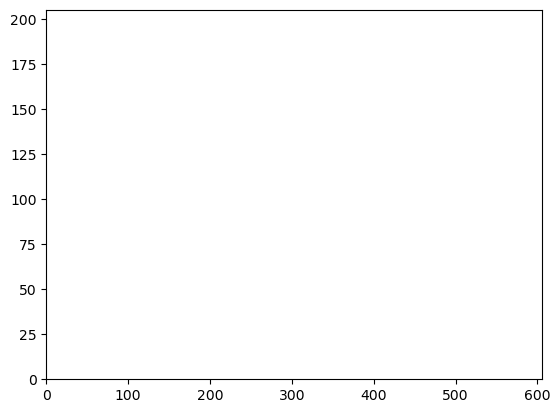

In [34]:
plt.contourf(dr_hycom2u_siu[211,:,:])

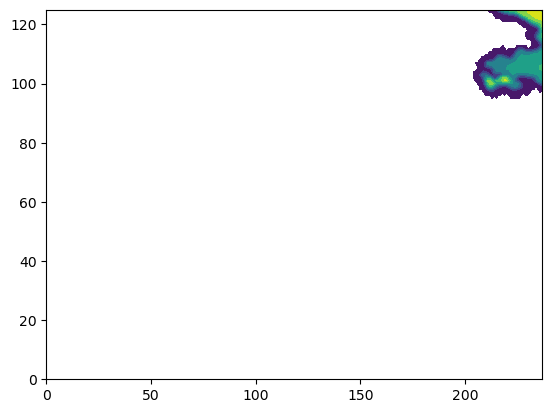

In [35]:
plt.contourf(hycom_ice_all.sih[211,:,:])

In [36]:
print(hycom_ice_all.time[211].values)

2019-07-31T09:00:00.000000000


In [37]:
# Replace all nans with 0 in the data since this seems to be coming
# from the summer when there is no sea ice in this region and the OG
# HYCOM data has all nans at these times 
dr_out_hycom2rho_sih_nonan[np.where(np.isnan(dr_out_hycom2rho_sih_nonan))] = 0.0 
dr_hycom2u_siu_nonan[np.where(np.isnan(dr_hycom2u_siu_nonan))] = 0.0 
dr_hycom2v_siv_nonan[np.where(np.isnan(dr_hycom2v_siv_nonan))] = 0.0 

In [38]:
# Check for nans again
print('nans (sic): ', np.where(np.isnan(dr_out_hycom2rho_sic_nonan)))
print('nans (sih): ', np.where(np.isnan(dr_out_hycom2rho_sih_nonan)))
print('nans (siu): ', np.where(np.isnan(dr_hycom2u_siu_nonan)))
print('nans (siv): ', np.where(np.isnan(dr_hycom2v_siv_nonan)))

nans (sic):  (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
nans (sih):  (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
nans (siu):  (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
nans (siv):  (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))


In [39]:
# Save the interpolated/regridded zeta to the netcdf files
# Sea ice concentration/area fraction
# to the climatology file
Aice_clm_g[:,:,:] = dr_out_hycom2rho_sic_nonan[:,:,:]
# to the boundary file
Aice_west_bry_g[:,:] = dr_out_hycom2rho_sic_nonan[:,:,0]
Aice_north_bry_g[:,:] = dr_out_hycom2rho_sic_nonan[:,-1,:]
Aice_east_bry_g[:,:] = dr_out_hycom2rho_sic_nonan[:,:,-1]

# Sea ice thickness
# to the climatology file
ice_thickness_clm_g[:,:,:] = dr_out_hycom2rho_sih_nonan[:,:,:]
# to the boundary file
ice_thickness_west_g[:,:] = dr_out_hycom2rho_sih_nonan[:,:,0]
ice_thickness_north_g[:,:] = dr_out_hycom2rho_sih_nonan[:,-1,:]
ice_thickness_east_g[:,:] = dr_out_hycom2rho_sih_nonan[:,:,-1]

# Sea ice u velocity 
# to the climatology file
Uice_clm_g[:,:,:] = dr_hycom2u_siu_nonan[:,:,:]
# to the boundary file
Uice_west_g[:,:] = dr_hycom2u_siu_nonan[:,:,0]
Uice_north_g[:,:] = dr_hycom2u_siu_nonan[:,-1,:]
Uice_east_g[:,:] = dr_hycom2u_siu_nonan[:,:,-1]

# Sea ice v velocity 
# to the climatology file
Vice_clm_g[:,:,:] = dr_hycom2v_siv_nonan[:,:,:]
# to the boundary file
Vice_west_g[:,:] = dr_hycom2v_siv_nonan[:,:,0]
Vice_north_g[:,:] = dr_hycom2v_siv_nonan[:,-1,:]
Vice_east_g[:,:] = dr_hycom2v_siv_nonan[:,:,-1]

In [40]:
# Close the netcdfs
nc1.close()
nc2.close()